<a href="https://colab.research.google.com/github/Gabrielrossimoras/praticas-extensionistas-iv/blob/main/EDA_Sprint4_Pratica_Extensionista_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!git clone https://github.com/Gabrielrossimoras/praticas-extensionistas-iv.git
%cd praticas-extensionistas-iv
!pip install pandas openpyxl
!python src/etl.py


Cloning into 'praticas-extensionistas-iv'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 102 (delta 37), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 377.71 KiB | 4.39 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/praticas-extensionistas-iv
ETL concluido: 7 atendimentos; 6 concluidos; 1 nao concluidos.
Arquivo gerado: /content/praticas-extensionistas-iv/dados/tratados/dataset_final_treinamento.csv
ATENCAO: esta base pequena serve para demonstracao, nao para validar modelo preditivo.


In [2]:

import pandas as pd

df = pd.read_csv(
    "/content/praticas-extensionistas-iv/dados/tratados/dataset_final_treinamento.csv"
)

print("Quantidade de registros:", len(df))
print("\nColunas do dataset:")
print(df.columns.tolist())

display(df)


Quantidade de registros: 7

Colunas do dataset:
['id_processo', 'data_abertura', 'tipo_servico', 'origem_atendimento', 'tipo_veiculo', 'status', 'data_conclusao', 'prazo_previsto', 'documentacao_pendente', 'valor_servico', 'dias_conclusao', 'prazo_dias', 'mes_abertura', 'dia_semana_abertura', 'concluido', 'atrasou']


,id_processo,data_abertura,tipo_servico,origem_atendimento,tipo_veiculo,status,data_conclusao,prazo_previsto,documentacao_pendente,valor_servico,dias_conclusao,prazo_dias,mes_abertura,dia_semana_abertura,concluido,atrasou
0,1,2026-09-28,licenciamento,cliente,automovel,concluido,2026-09-28,2026-10-01,nao,70,0.0,3,9,0,1,0.0
1,2,2026-09-29,transferencia,cliente,automovel,concluido,2026-09-30,2026-10-02,nao,150,1.0,3,9,1,1,0.0
2,3,2026-09-30,transferencia,cliente,automovel,concluido,2026-09-30,2026-10-03,nao,150,0.0,3,9,2,1,0.0
3,4,2026-10-01,licenciamento,cliente,motocicleta,concluido,2026-10-01,2026-10-04,nao,70,0.0,3,10,3,1,0.0
4,5,2026-10-02,licenciamento,cliente,automovel,concluido,2026-10-05,2026-10-05,nao,70,3.0,3,10,4,1,0.0
5,6,2026-10-05,transferencia,cliente,motocicleta,pendente,NaN,2026-10-08,vistoria,150,NaN,3,10,0,0,NaN
6,7,2026-10-06,licenciamento,cliente,caminhao,concluido,2026-10-06,2026-10-09,nao,70,0.0,3,10,1,1,0.0


In [3]:

from google.colab import files

files.download(
    "/content/praticas-extensionistas-iv/dados/tratados/dataset_final_treinamento.csv"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Atendimentos por tipo de serviço:
tipo_servico
licenciamento    4
transferencia    3
Name: count, dtype: int64


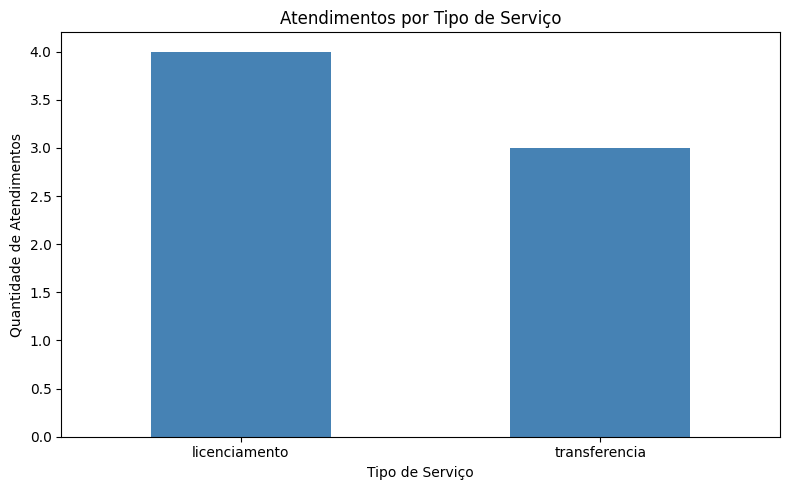

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/praticas-extensionistas-iv/dados/tratados/dataset_final_treinamento.csv"
)

# Quantidade de atendimentos por serviço
contagem = df["tipo_servico"].value_counts()

print("Atendimentos por tipo de serviço:")
print(contagem)

plt.figure(figsize=(8, 5))
contagem.plot(kind="bar", color="steelblue")

plt.title("Atendimentos por Tipo de Serviço")
plt.xlabel("Tipo de Serviço")
plt.ylabel("Quantidade de Atendimentos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Tempo médio de conclusão: 0.67 dias


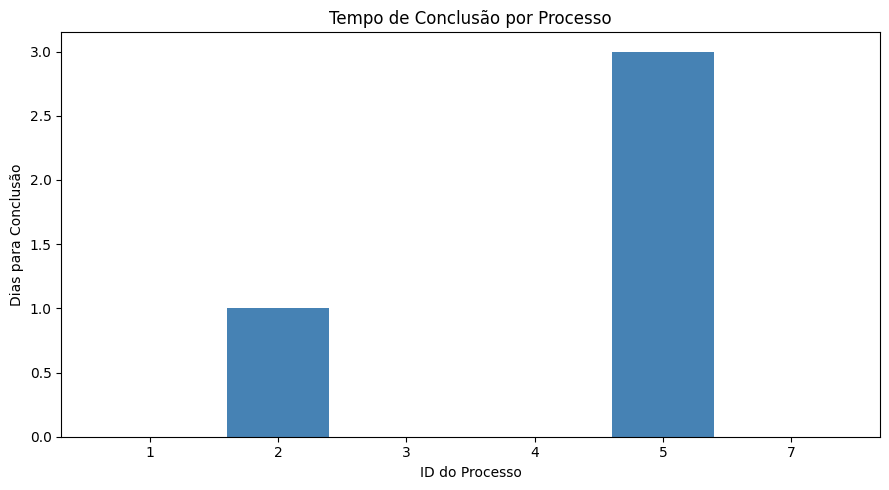

In [5]:

import matplotlib.pyplot as plt

# Considerar somente processos concluídos
concluidos = df[df["status"] == "concluido"].copy()

# Calcular o tempo médio de conclusão
media = concluidos["dias_conclusao"].mean()

print(f"Tempo médio de conclusão: {media:.2f} dias")

# Gráfico do tempo de conclusão por processo
plt.figure(figsize=(9, 5))

plt.bar(
    concluidos["id_processo"].astype(str),
    concluidos["dias_conclusao"],
    color="steelblue"
)

plt.title("Tempo de Conclusão por Processo")
plt.xlabel("ID do Processo")
plt.ylabel("Dias para Conclusão")
plt.tight_layout()
plt.show()


Situação dos prazos:
situacao_prazo
Dentro do prazo    6
Name: count, dtype: int64


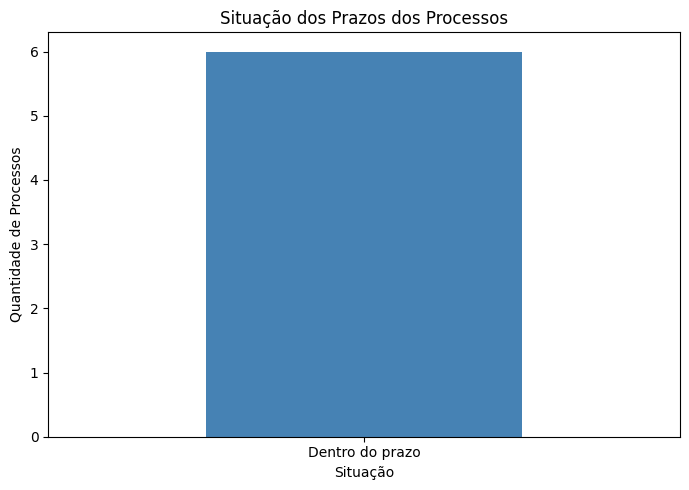

In [6]:

import pandas as pd
import matplotlib.pyplot as plt

# Considerar somente processos concluídos
concluidos = df[df["status"] == "concluido"].copy()

# Converter as datas
concluidos["data_conclusao"] = pd.to_datetime(
    concluidos["data_conclusao"]
)
concluidos["prazo_previsto"] = pd.to_datetime(
    concluidos["prazo_previsto"]
)

# Identificar atrasos
concluidos["situacao_prazo"] = (
    concluidos["data_conclusao"] > concluidos["prazo_previsto"]
).map({
    True: "Atrasado",
    False: "Dentro do prazo"
})

resultado = concluidos["situacao_prazo"].value_counts()

print("Situação dos prazos:")
print(resultado)

plt.figure(figsize=(7, 5))
resultado.plot(kind="bar", color="steelblue")

plt.title("Situação dos Prazos dos Processos")
plt.xlabel("Situação")
plt.ylabel("Quantidade de Processos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Valores por tipo de serviço:
tipo_servico
licenciamento    280
transferencia    450
Name: valor_servico, dtype: int64

Valor total registrado: R$ 730.00


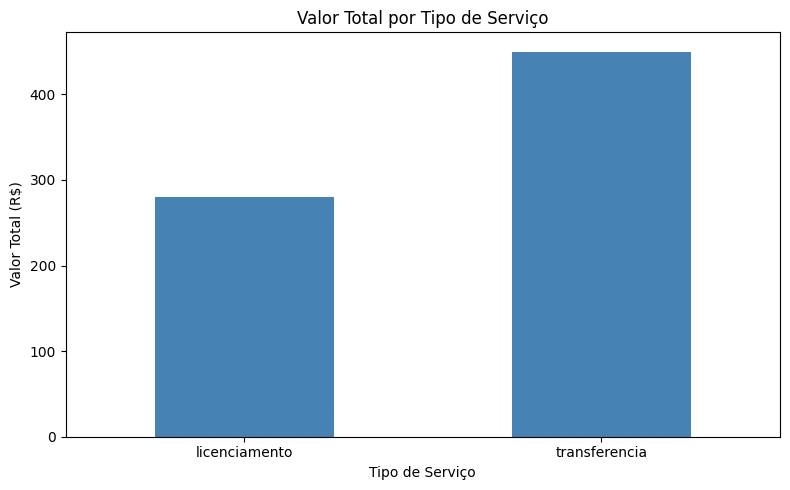

Valores por tipo de serviço:
tipo_servico
licenciamento    280
transferencia    450
Name: valor_servico, dtype: int64

Valor total registrado: R$ 730.00


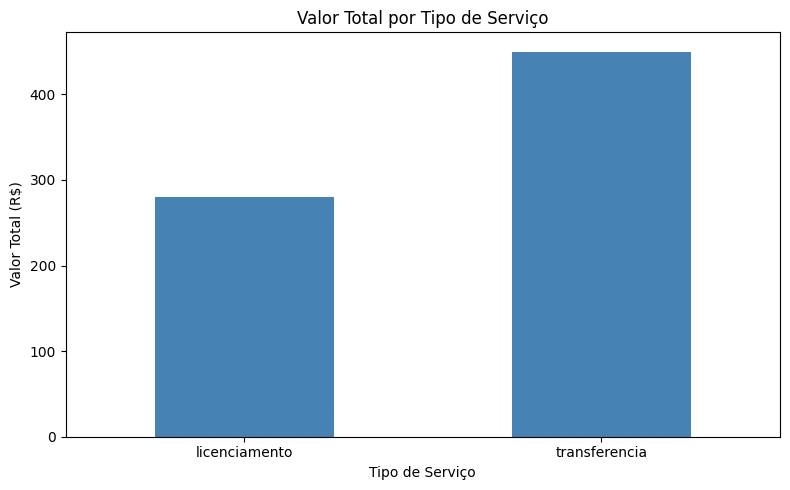

In [8]:

import matplotlib.pyplot as plt

# Somar os valores por tipo de serviço
valores = df.groupby("tipo_servico")["valor_servico"].sum()

print("Valores por tipo de serviço:")
print(valores)

print(f"\nValor total registrado: R$ {df['valor_servico'].sum():.2f}")

plt.figure(figsize=(8, 5))
valores.plot(kind="bar", color="steelblue")

plt.title("Valor Total por Tipo de Serviço")
plt.xlabel("Tipo de Serviço")
plt.ylabel("Valor Total (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
